In [1]:
library(CellChat)

Loading required package: dplyr

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: ggplot2



In [2]:
library(Seurat)
library(SingleCellExperiment)
library(patchwork)
library(dplyr)
library(SeuratData)
library(ggplot2)
library(ggalluvial)
library(svglite)

Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.2”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.2”
‘SeuratObject’ was built with package ‘Matrix’ 1.6.3 but the current
version is 1.6.5; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:BiocGenerics’:

    intersect


The following object is masked from ‘package:base’:

    intersect



Attaching package: ‘Seurat’


The following object is masked from ‘package:igraph’:

    components


Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following objects are masked from ‘package:Biobase’:

    anyMissing, rowMedians


The following object is masked from ‘package:dplyr’:

    count



Attachi

In [3]:
library(reticulate)
Sys.setenv(RETICULATE_PYTHON="/cluster/apps/anaconda3/2022.10/envs/scanpy-env/bin/python")
py_config()
use_condaenv("/cluster/apps/anaconda3/2022.10/envs/scanpy-env")

Warning message:
“package ‘reticulate’ was built under R version 4.3.1”


python:         /cluster/apps/anaconda3/2022.10/envs/scanpy-env/bin/python
libpython:      /cluster/apps/anaconda3/2022.10/envs/scanpy-env/lib/libpython3.9.so
pythonhome:     /cluster/apps/anaconda3/2022.10/envs/scanpy-env:/cluster/apps/anaconda3/2022.10/envs/scanpy-env
version:        3.9.16 | packaged by conda-forge | (main, Feb  1 2023, 21:39:03)  [GCC 11.3.0]
numpy:          /cluster/home/chenyulong/.local/lib/python3.9/site-packages/numpy
numpy_version:  1.26.4

NOTE: Python version was forced by RETICULATE_PYTHON

In [4]:
safe_factor_conversion <- function(py_series) {
  tryCatch({
    py_run_string("
def get_categorical_data(series):
    if hasattr(series, 'cat'):
        return {
            'codes': series.cat.codes.to_numpy(),
            'categories': series.cat.categories.to_list()
        }
    else:
        return series.astype(str).to_numpy()
")
    res <- py$get_categorical_data(py_series)
    
    if (is.list(res)) {  
      codes <- res$codes + 1L  
      valid_codes <- codes >= 1L & codes <= length(res$categories)
      if (!all(valid_codes, na.rm = TRUE)) {
        warning("检测到", sum(!valid_codes), "个无效分类编码，转换为NA")
        codes[!valid_codes] <- NA
      }
      factor(codes, 
             levels = seq_along(res$categories), 
             labels = res$categories)
    } else {            
      factor(res)
    }
  }, error = function(e) {
    message("转换失败，使用强制转换: ", e$message)
    factor(py_to_r(py_series$astype("str")))
  })
}

In [111]:
total9dfu_cells <- which(total9_sce$group == "DFU")
if(length(total9dfu_cells) == 0) stop("未找到DFU细胞")

In [112]:
total9dfu_sce <- total9_sce[, total9dfu_cells, drop = FALSE]

In [113]:
reducedDims(total9dfu_sce) <- list(
  PCA = reducedDim(total9dfu_sce, "PCA"),
  Harmony = reducedDim(total9dfu_sce, "Harmony"), 
  UMAP = reducedDim(total9dfu_sce, "UMAP")
)
names(reducedDims(total9dfu_sce)) <- c("PCA", "Harmony", "UMAP")

In [114]:
counts <- assay(total9dfu_sce, "counts")
meta <- as.data.frame(colData(total9dfu_sce))

In [115]:
rownames(meta) <- colnames(counts)

In [116]:
total9dfu_cellchat <- createCellChat(
  object = counts,
  meta = meta,
  group.by = "cell_type"  
)

[1] "Create a CellChat object from a data matrix"
The cell barcodes in 'meta' is  1 2 3 4 5 6 
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  VSMC Fibroblast Endothelial Cell Keratinocyte Macrophage T Cell B Cell Melanocyte 


In [117]:
CellChatDB <- CellChatDB.human
total9dfu_cellchat@DB <- CellChatDB

In [118]:
table(meta$cell_type)


            VSMC       Fibroblast Endothelial Cell     Keratinocyte 
           10629             9718             3578             3879 
      Macrophage           T Cell           B Cell       Melanocyte 
            4371             4179             1140              266 

In [119]:
total9dfu_cellchat <- subsetData(total9dfu_cellchat)

In [120]:
total9dfu_cellchat <- identifyOverExpressedGenes(total9dfu_cellchat)
total9dfu_cellchat <- identifyOverExpressedInteractions(total9dfu_cellchat)

In [121]:
total9dfu_cellchat <- computeCommunProb(total9dfu_cellchat)

triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2025-04-24 21:38:12.689986]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2025-04-24 21:41:48.92443]"


In [122]:
total9dfu_cellchat <- filterCommunication(total9dfu_cellchat, min.cells = 10)

In [123]:
total9dfu_cellchat <- computeCommunProbPathway(total9dfu_cellchat)

In [124]:
total9dfu_cellchat <- aggregateNet(total9dfu_cellchat)

In [125]:
total9dfu_cellchat@net$count
total9dfu_cellchat@net$weight

,VSMC,Fibroblast,Endothelial Cell,Keratinocyte,Macrophage,T Cell,B Cell,Melanocyte
VSMC,0,1,3,12,2,1,1,0
Fibroblast,0,2,8,28,9,1,1,0
Endothelial Cell,0,1,9,15,12,1,1,1
Keratinocyte,0,1,4,11,0,0,0,1
Macrophage,0,2,13,5,18,1,4,0
T Cell,0,3,6,1,6,3,1,0
B Cell,0,0,2,0,9,1,0,0
Melanocyte,0,0,0,8,1,0,0,2


,VSMC,Fibroblast,Endothelial Cell,Keratinocyte,Macrophage,T Cell,B Cell,Melanocyte
VSMC,0,0.0014674539,0.011883875,0.229948843,0.004195999,0.0137528513,0.006070781,0.000000000
Fibroblast,0,0.0080503593,0.021386610,0.493621081,0.045789574,0.0563829843,0.025504353,0.000000000
Endothelial Cell,0,0.0009416968,0.137808199,0.062655693,0.062704490,0.0088645766,0.003902196,0.011282295
Keratinocyte,0,0.0012544398,0.009404377,0.049830973,0.000000000,0.0000000000,0.000000000,0.001014013
Macrophage,0,0.0056882671,0.188530805,0.007523872,0.357141058,0.0007964209,0.007748887,0.000000000
T Cell,0,0.0064344511,0.023221955,0.001212644,0.064153726,0.0826529914,0.001436472,0.000000000
B Cell,0,0.0000000000,0.006642603,0.000000000,0.169930705,0.0409987405,0.000000000,0.000000000
Melanocyte,0,0.0000000000,0.000000000,0.017586960,0.006752787,0.0000000000,0.000000000,0.001596129


In [126]:
# 保存 count 矩阵
write.csv(total9dfu_cellchat@net$count, file = "/cluster/home/chenyulong/GSE165816/0.1out/total9DFU_net_count.csv")

# 保存 weight 矩阵
write.csv(total9dfu_cellchat@net$weight, file = "/cluster/home/chenyulong/GSE165816/0.1out/total9DFU_net_weight.csv")

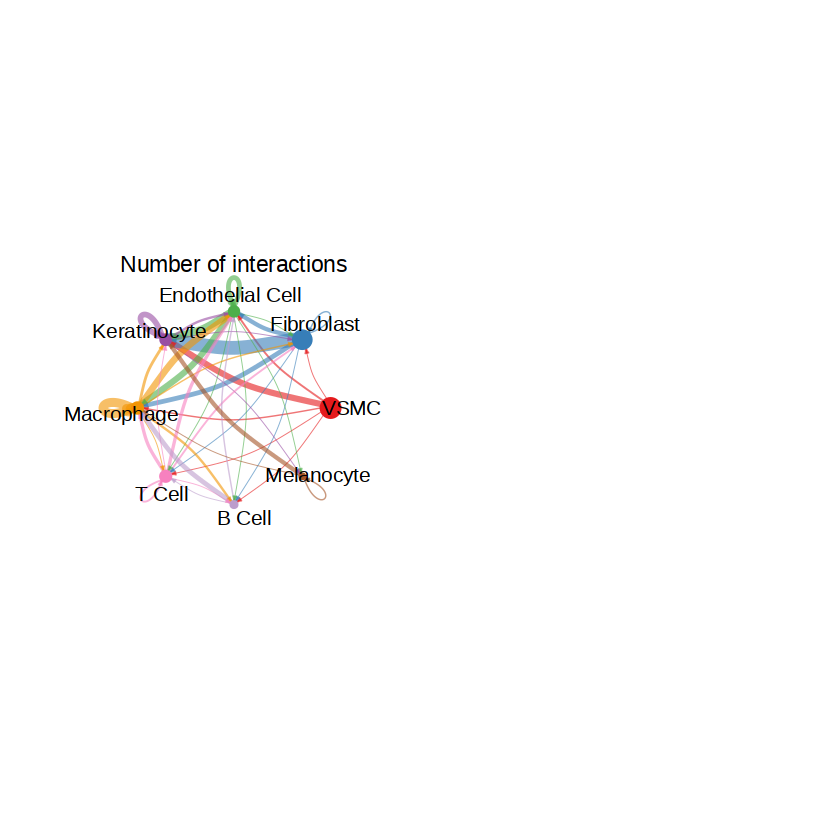

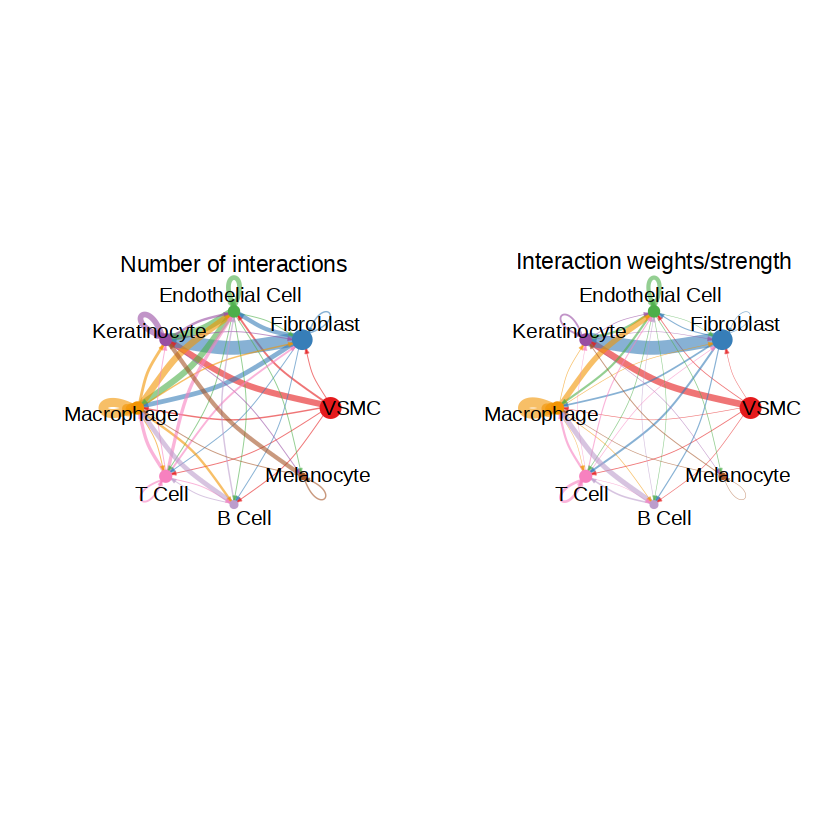

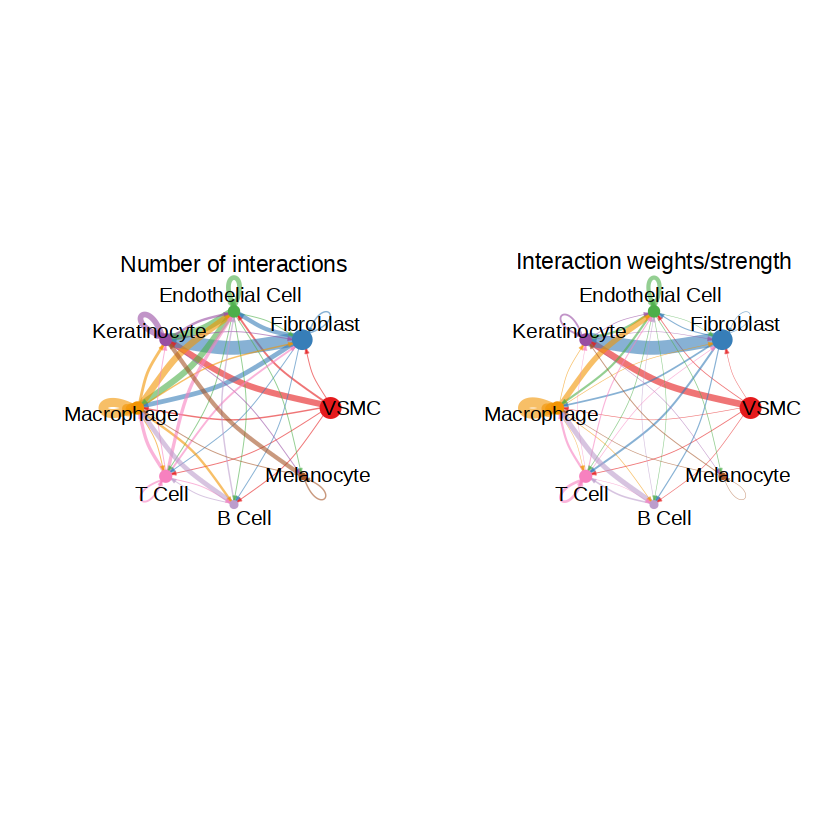

In [127]:
groupSize <- as.numeric(table(total9dfu_cellchat@idents))
par(mfrow = c(1, 2), xpd = TRUE)
netVisual_circle(total9dfu_cellchat@net$count, vertex.weight = groupSize, weight.scale = T, label.edge= F, title.name = "Number of interactions")
netVisual_circle(total9dfu_cellchat@net$weight, vertex.weight = groupSize, weight.scale = T, label.edge= F, title.name = "Interaction weights/strength")

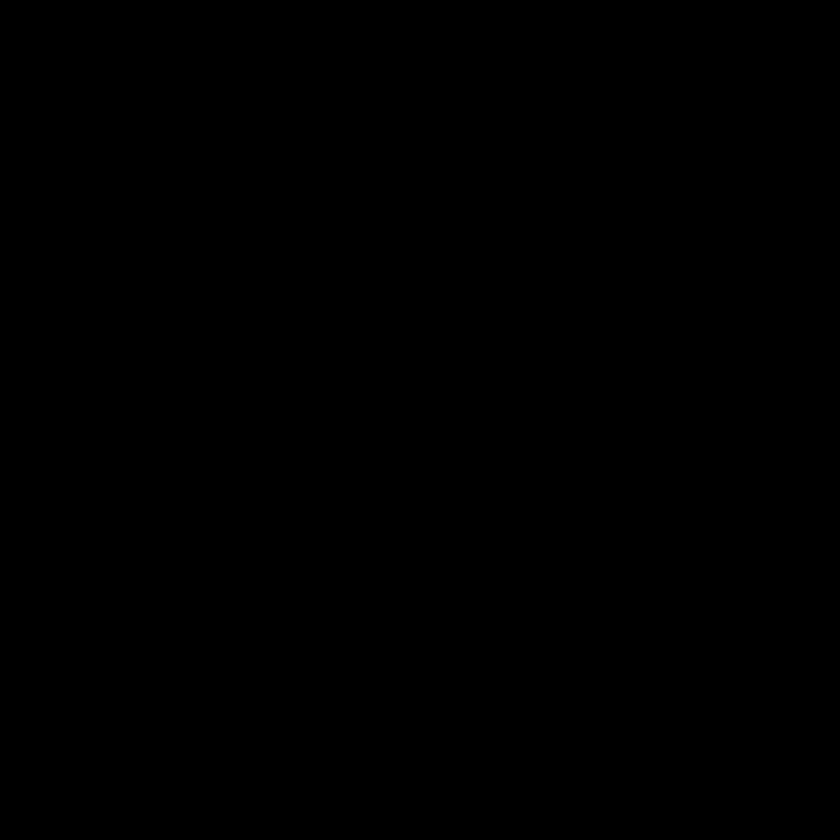

pdf 
  3

✅ 已保存：total9dfu_interactions_count.pdf



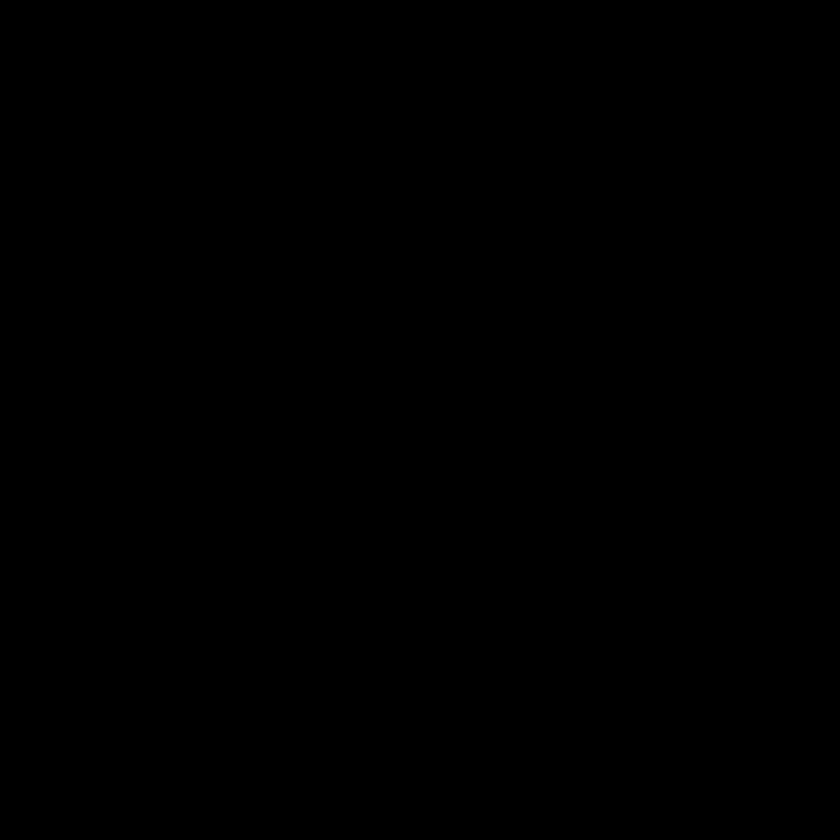

pdf 
  3

✅ 已保存：total9dfu_interactions_weight.pdf



In [198]:
celltype_order <- c("VSMC", "Fibroblast", "Endothelial Cell", "Keratinocyte", "Macrophage", "T Cell", "B Cell", "Melanocyte")
color_vector <- c(
  'VSMC' = '#1f77b4',
  'Fibroblast' = '#ff7f0e',
  'Endothelial Cell' = '#279e68',
  'Keratinocyte' = '#d62728',
  'Macrophage' = '#aa40fc',
  'T Cell' = '#8c564b',
  'B Cell' = '#e377c2',
  'Melanocyte' = '#b5bd61'
)

total9dfu_cellchat@idents <- factor(total9dfu_cellchat@idents, levels = celltype_order)
groupSize <- as.numeric(table(total9dfu_cellchat@idents))

mat_count <- total9dfu_cellchat@net$count[celltype_order, celltype_order]
mat_weight <- total9dfu_cellchat@net$weight[celltype_order, celltype_order]


pdf("/cluster/home/chenyulong/GSE165816/0.1out/total9dfu_interactions_count.pdf", width = 7, height = 7)
netVisual_circle(
  mat_count,
  vertex.weight = groupSize,
  weight.scale = TRUE,
  label.edge = FALSE,
  vertex.label.cex = 0.001,
  color.use = color_vector[celltype_order],
  title.name = "Number of interactions"
)
dev.off()
message("已保存：total9dfu_interactions_count.pdf")

pdf("/cluster/home/chenyulong/GSE165816/0.1out/total9dfu_interactions_weight.pdf", width = 7, height = 7)
netVisual_circle(
  mat_weight,
  vertex.weight = groupSize,
  weight.scale = TRUE,
  label.edge = FALSE,
  color.use = color_vector[celltype_order],
  title.name = "Interaction weights/strength"
)
dev.off()
message("已保存：total9dfu_interactions_weight.pdf")

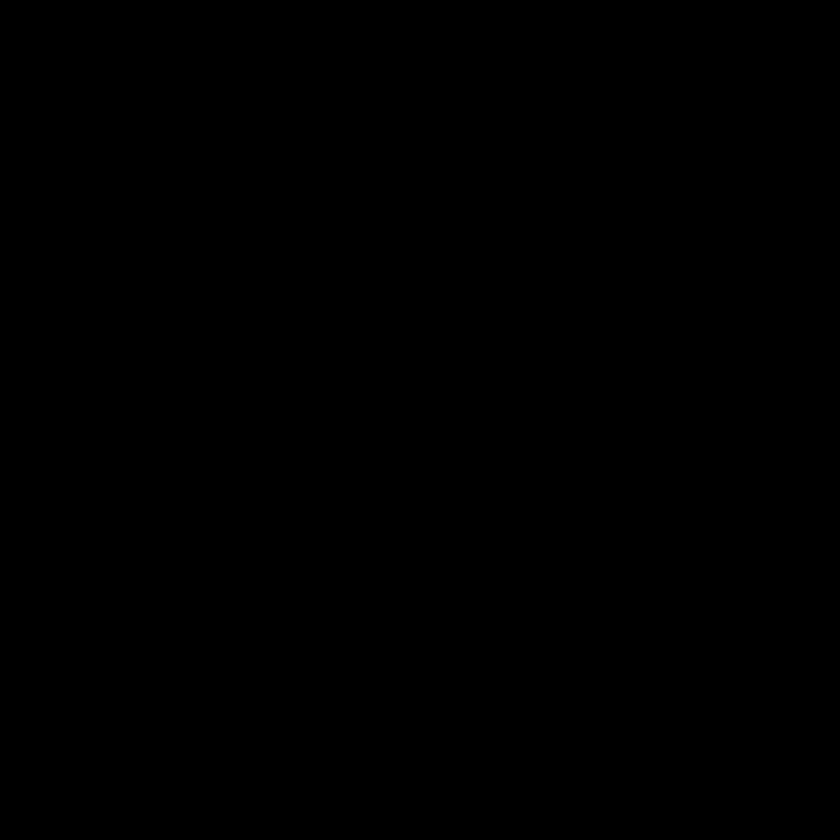

pdf 
  3

✅ 尝试重新绘制并保存 count 图完成



In [199]:
graphics.off()  

pdf("/cluster/home/chenyulong/GSE165816/0.1out/total9dfu_interactions_count.pdf", width = 7, height = 7)

tryCatch({
  netVisual_circle(
    mat_count,
    vertex.weight = groupSize,
    weight.scale = TRUE,
    label.edge = FALSE,
    color.use = color_vector[celltype_order],
    title.name = "Number of interactions"
  )
}, error = function(e) {
  message(" 绘图出错：", e$message)
})

dev.off()
message(" 尝试重新绘制并保存 count 图完成")

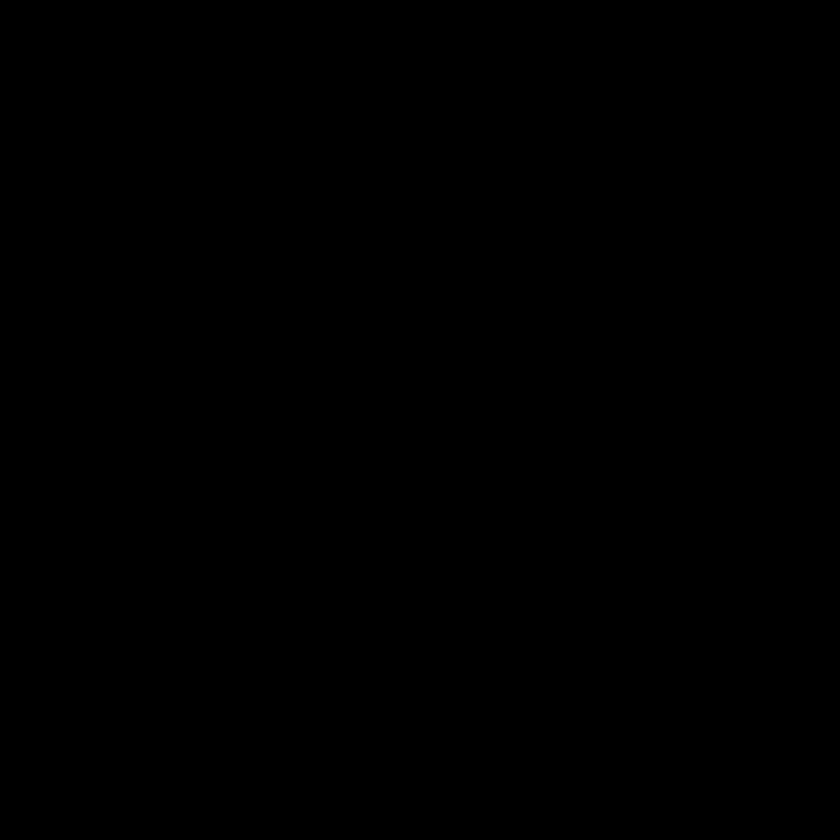

pdf 
  3

✅ 已保存：total9nodfu_interactions_count.pdf



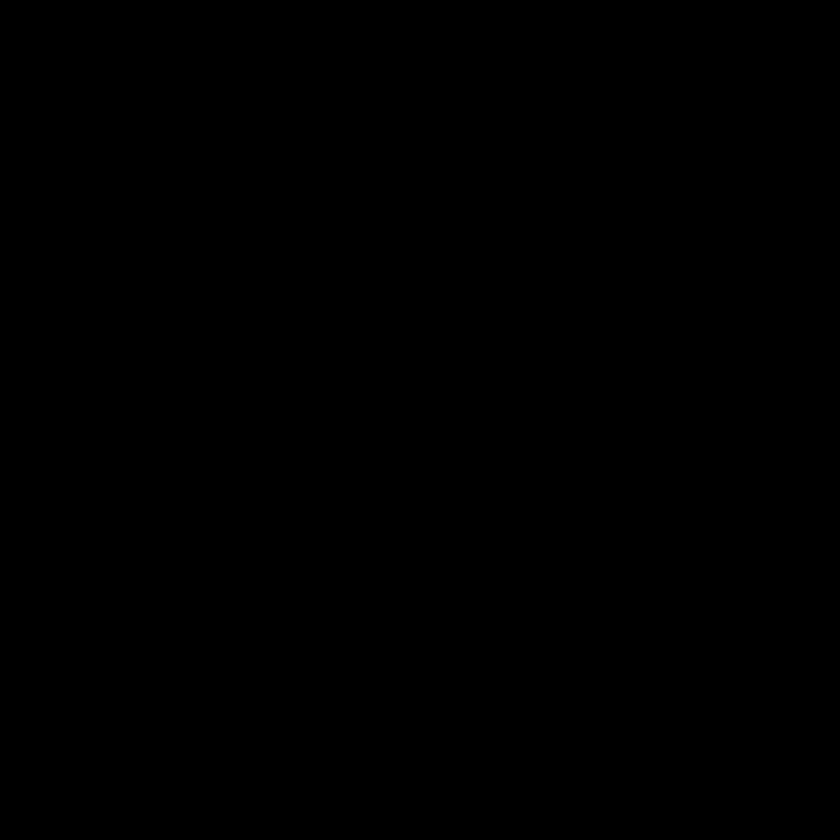

pdf 
  3

✅ 已保存：total9dfuno_interactions_weight.pdf



In [200]:
celltype_order <- c("VSMC", "Fibroblast", "Endothelial Cell", "Keratinocyte", "Macrophage", "T Cell", "B Cell", "Melanocyte")
color_vector <- c(
  'VSMC' = '#1f77b4',
  'Fibroblast' = '#ff7f0e',
  'Endothelial Cell' = '#279e68',
  'Keratinocyte' = '#d62728',
  'Macrophage' = '#aa40fc',
  'T Cell' = '#8c564b',
  'B Cell' = '#e377c2',
  'Melanocyte' = '#b5bd61'
)


total9dfu_cellchat@idents <- factor(total9dfu_cellchat@idents, levels = celltype_order)
groupSize <- as.numeric(table(total9dfu_cellchat@idents))


mat_count <- total9dfu_cellchat@net$count[celltype_order, celltype_order]
mat_weight <- total9dfu_cellchat@net$weight[celltype_order, celltype_order]

pdf("/cluster/home/chenyulong/GSE165816/0.1out/total9dfuno_interactions_count.pdf", width = 7, height = 7)
netVisual_circle(
  mat_count,
  vertex.weight = groupSize,
  weight.scale = TRUE,
  label.edge = FALSE,
  vertex.label.cex = 0.001,
  color.use = color_vector[celltype_order],
  title.name = "Number of interactions"
)
dev.off()
message("已保存：total9nodfu_interactions_count.pdf")


pdf("/cluster/home/chenyulong/GSE165816/0.1out/total9dfuno_interactions_weight.pdf", width = 7, height = 7)
netVisual_circle(
  mat_weight,
  vertex.weight = groupSize,
  weight.scale = TRUE,
  label.edge = FALSE,
  vertex.label.cex = 0.001,
  color.use = color_vector[celltype_order],
  title.name = "Interaction weights/strength"
)
dev.off()
message(" 已保存：total9dfuno_interactions_weight.pdf")

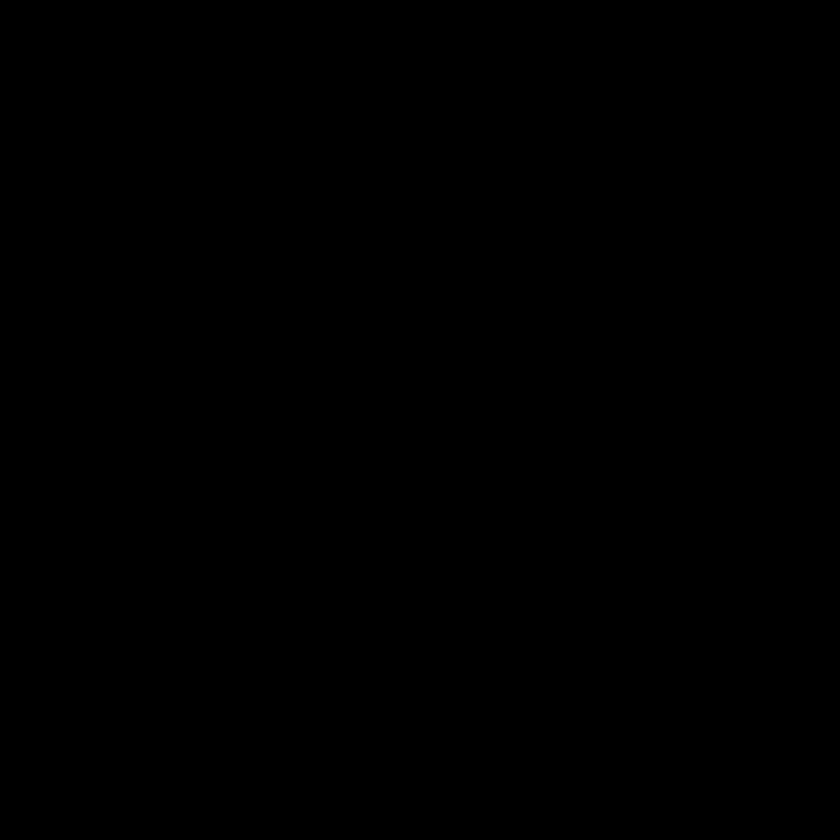

pdf 
  3

✅ 尝试重新绘制并保存 count 图完成



In [201]:
graphics.off()  

pdf("/cluster/home/chenyulong/GSE165816/0.1out/total9nodfu_interactions_count.pdf", width = 7, height = 7)

tryCatch({
  netVisual_circle(
    mat_count,
    vertex.weight = groupSize,
    weight.scale = TRUE,
    label.edge = FALSE,
    color.use = color_vector[celltype_order],
    title.name = "Number of interactions"
  )
}, error = function(e) {
  message("绘图出错：", e$message)
})

dev.off()
message(" 尝试重新绘制并保存 count 图完成")

# 5CellChat

## all

In [5]:
ad <- import("anndata", convert = FALSE)
ad_object <- ad$read_h5ad("/cluster/home/chenyulong/GSE165816/0.1out/5cellchat.h5ad")

In [6]:

cell_type_col <- safe_factor_conversion(ad_object$obs$celltype)
leiden_col <- safe_factor_conversion(ad_object$obs$leiden)
group_col <- safe_factor_conversion(ad_object$obs$group)

n_cells <- ncol(ad_object$X)
stopifnot(
  length(cell_type_col) == n_cells,
  length(leiden_col) == n_cells,
  length(group_col) == n_cells
)

In [7]:
pca_matrix <- py_to_r(ad_object$obsm$get("X_pca"))[, 1:30]
harmony_matrix <- py_to_r(ad_object$obsm$get("X_pca_harmony"))
umap_matrix <- py_to_r(ad_object$obsm$get("X_umap"))


stopifnot(
  nrow(pca_matrix) == n_cells,
  nrow(harmony_matrix) == n_cells,
  nrow(umap_matrix) == n_cells
)

In [8]:
cat("\n降维矩阵维度：\n")
cat("PCA:", dim(pca_matrix), "\n")         
cat("Harmony:", dim(harmony_matrix), "\n")  
cat("UMAP:", dim(umap_matrix), "\n")        


降维矩阵维度：
PCA: 16877 30 
Harmony: 16877 50 
UMAP: 16877 2 


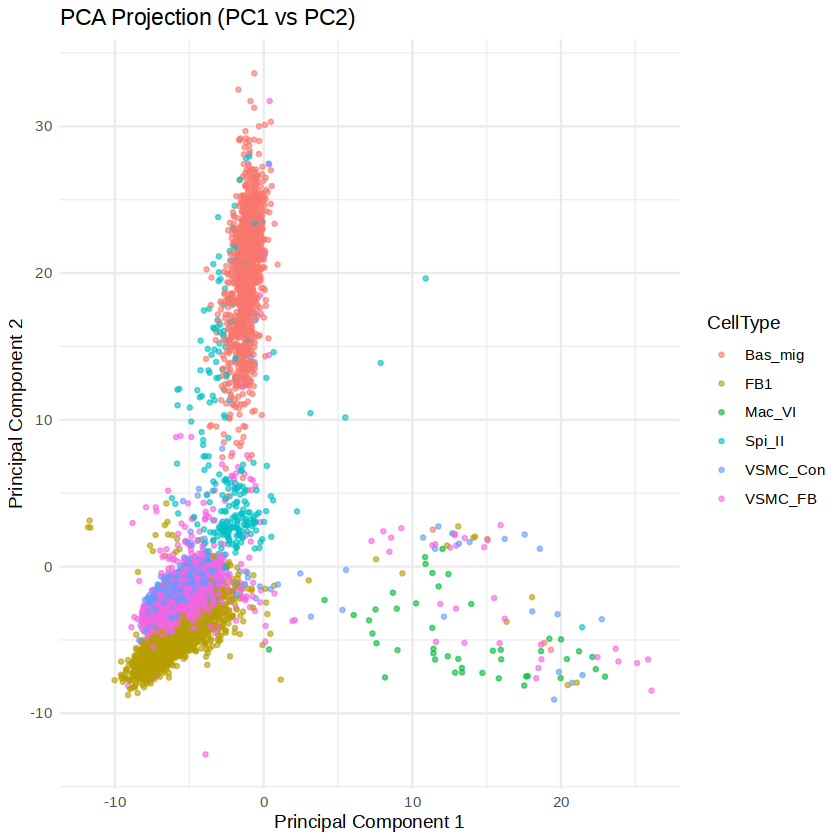

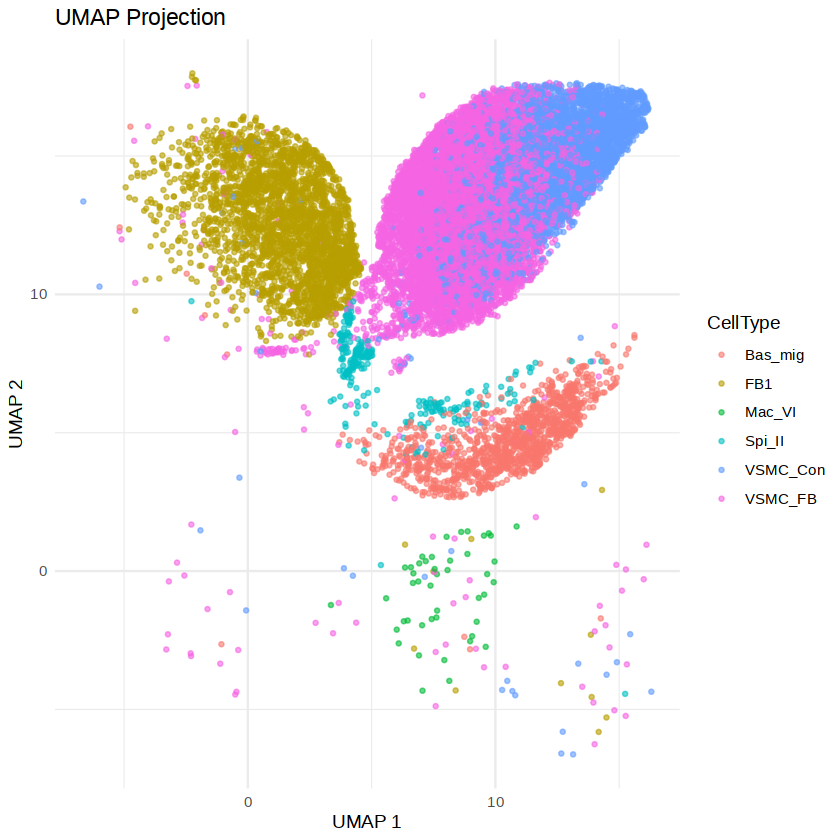

In [9]:
if (requireNamespace("ggplot2", quietly = TRUE)) {
  library(ggplot2)

  plot_df <- data.frame(
    PC1 = pca_matrix[, 1],
    PC2 = pca_matrix[, 2],
    CellType = head(cell_type_col, nrow(pca_matrix))  
  )
  
  p_pca <- ggplot(plot_df, aes(x = PC1, y = PC2, color = CellType)) +
    geom_point(alpha = 0.6, size = 0.8) +
    labs(title = "PCA Projection (PC1 vs PC2)",
         x = "Principal Component 1",
         y = "Principal Component 2") +
    theme_minimal()
  print(p_pca)
  
  if (ncol(umap_matrix) >= 2) {
    umap_df <- data.frame(
      UMAP1 = umap_matrix[, 1],
      UMAP2 = umap_matrix[, 2],
      CellType = head(cell_type_col, nrow(umap_matrix))
    )
    
    p_umap <- ggplot(umap_df, aes(x = UMAP1, y = UMAP2, color = CellType)) +
      geom_point(alpha = 0.6, size = 0.8) +
      labs(title = "UMAP Projection",
           x = "UMAP 1",
           y = "UMAP 2") +
      theme_minimal()
    print(p_umap)
  }
} else {
  message("安装ggplot2以获得更好可视化：install.packages('ggplot2')")
}

In [10]:
if (inherits(py_to_r(ad_object$X), "scipy.sparse.csr.csr_matrix")) {
  
  counts_matrix <- t(py_to_r(ad_object$X$toarray()))
} else {
  
  counts_matrix <- t(py_to_r(ad_object$X))
}

In [11]:
n_genes <- py_to_r(ad_object$n_vars)

stopifnot(
  nrow(counts_matrix) == n_genes,                   
  length(py_to_r(ad_object$var$n_cells$values)) == n_genes, 
  length(py_to_r(ad_object$var$mt$values)) == n_genes       
)

In [12]:
n_cells_var <- as.integer(py_to_r(ad_object$var$n_cells$to_numpy()))  # 使用 to_numpy()
mt_var <- as.logical(py_to_r(ad_object$var$mt$to_numpy()))

gene_names <- rownames(counts_matrix) <- py_to_r(ad_object$var_names$to_numpy())

In [13]:
total5_sce <- SingleCellExperiment(
  assays = list(
    counts = counts_matrix,
    logcounts = log2(counts_matrix + 1) 
  ),
  colData = DataFrame(
    cell_type = cell_type_col,
    leiden = leiden_col,
    group = group_col
  ),
  rowData = DataFrame(
    gene_name = gene_names,
    n_cells = n_cells_var,
    mt = mt_var
  )
)

In [14]:
rownames(pca_matrix) <- colnames(total5_sce)
rownames(harmony_matrix) <- colnames(total5_sce)
rownames(umap_matrix) <- colnames(total5_sce)

reducedDims(total5_sce) <- list(
  PCA = pca_matrix,
  Harmony = harmony_matrix,
  UMAP = umap_matrix
)

In [15]:
unique(total5_sce$cell_type)
table(total5_sce$cell_type)

[1] FB1      Bas_mig  VSMC_FB  VSMC_Con Spi_II   Mac_VI  
Levels: Bas_mig FB1 Mac_VI Spi_II VSMC_Con VSMC_FB


 Bas_mig      FB1   Mac_VI   Spi_II VSMC_Con  VSMC_FB 
    1221     2864       45      267     4284     8196 

In [16]:
total5_sce <- total5_sce[, total5_sce$cell_type != "Unknown"]

In [17]:
table(total5_sce$cell_type)  


 Bas_mig      FB1   Mac_VI   Spi_II VSMC_Con  VSMC_FB 
    1221     2864       45      267     4284     8196 

In [18]:
counts <- assay(total5_sce, "counts")
meta <- as.data.frame(colData(total5_sce))

In [19]:
rownames(meta) <- colnames(counts)

In [20]:
total5_cellchat <- createCellChat(
  object = counts,
  meta = meta,
  group.by = "cell_type"  
)

[1] "Create a CellChat object from a data matrix"
The cell barcodes in 'meta' is  1 2 3 4 5 6 


Warning message in createCellChat(object = counts, meta = meta, group.by = "cell_type"):
“The cell barcodes in 'meta' is different from those in the used data matrix.
              We now simply assign the colnames in the data matrix to the rownames of 'mata'!”


Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Bas_mig FB1 Mac_VI Spi_II VSMC_Con VSMC_FB 


In [21]:
total5_cellchat
summary(total5_cellchat)
str(total5_cellchat)

An object of class CellChat created from a single dataset 
 4000 genes.
 16877 cells. 
CellChat analysis of single cell RNA-seq data! 

  Length    Class     Mode 
       1 CellChat       S4 

Formal class 'CellChat' [package "CellChat"] with 15 slots
  ..@ data.raw      : num[0 , 0 ] 
  ..@ data          :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. ..@ i       : int [1:3010605] 4 368 378 596 609 680 699 717 726 728 ...
  .. .. ..@ p       : int [1:16878] 0 147 349 479 578 667 882 1097 1206 1299 ...
  .. .. ..@ Dim     : int [1:2] 4000 16877
  .. .. ..@ Dimnames:List of 2
  .. .. .. ..$ : chr [1:4000] "A2M-AS1" "A2ML1" "AARD" "AATK" ...
  .. .. .. ..$ : NULL
  .. .. ..@ x       : num [1:3010605] 1.35 1.35 1.35 1.35 1.35 ...
  .. .. ..@ factors : list()
  ..@ data.signaling: num[0 , 0 ] 
  ..@ data.scale    : num[0 , 0 ] 
  ..@ data.project  : num[0 , 0 ] 
  ..@ images        : list()
  ..@ net           : list()
  ..@ netP          : list()
  ..@ meta          :'data.frame':	16877 obs. of  3 variables:
  .. ..$ cell_type: Factor w/ 6 levels "Bas_mig","FB1",..: 2 2 2 2 1 6 2 2 1 2 ...
  .. ..$ leiden   : Factor w/ 8 levels "B Cell","Endothelial Cell",..: 

In [22]:
CellChatDB <- CellChatDB.human
total5_cellchat@DB <- CellChatDB

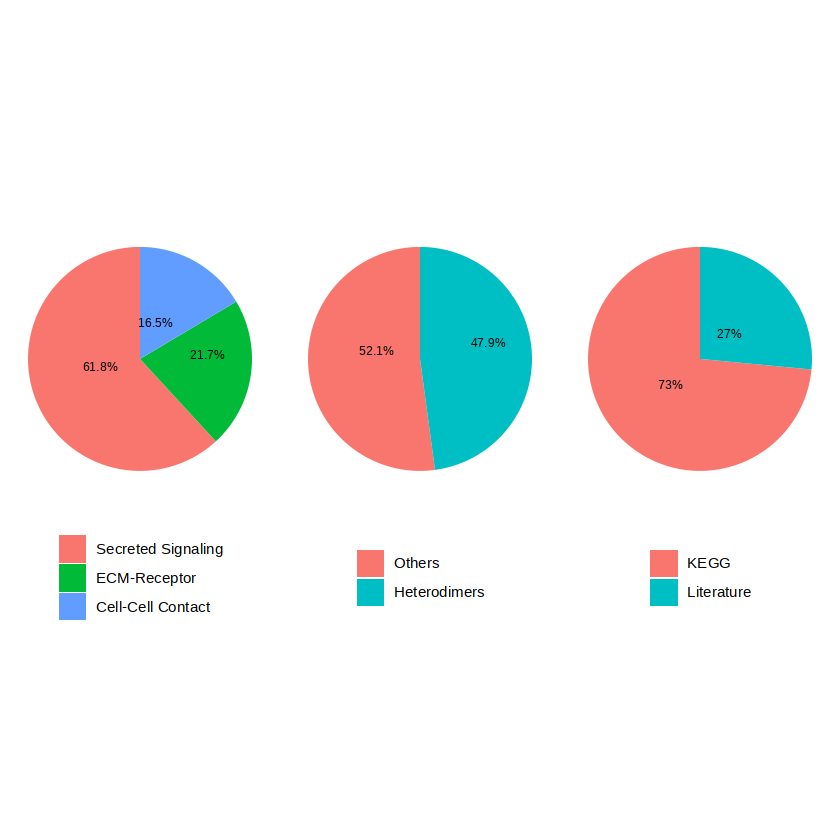

In [23]:
showDatabaseCategory(CellChatDB)

In [24]:
table(meta$cell_type)


 Bas_mig      FB1   Mac_VI   Spi_II VSMC_Con  VSMC_FB 
    1221     2864       45      267     4284     8196 

In [25]:
total5_cellchat@idents <- droplevels(total5_cellchat@idents)

In [26]:
total5_cellchat <- subsetData(total5_cellchat)

In [27]:
total5_cellchat <- identifyOverExpressedGenes(total5_cellchat)
total5_cellchat <- identifyOverExpressedInteractions(total5_cellchat)

In [28]:
total5_cellchat <- computeCommunProb(total5_cellchat)

triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2025-09-18 15:19:21.799584]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2025-09-18 15:20:53.731444]"


In [29]:
total5_cellchat <- filterCommunication(total5_cellchat, min.cells = 10)

In [30]:
total5_cellchat <- computeCommunProbPathway(total5_cellchat)

In [31]:
total5_cellchat <- aggregateNet(total5_cellchat)

In [32]:
total5_cellchat@net$count
total5_cellchat@net$weight

,Bas_mig,FB1,Mac_VI,Spi_II,VSMC_Con,VSMC_FB
Bas_mig,10,7,0,8,0,0
FB1,21,22,10,21,2,1
Mac_VI,13,15,20,13,1,0
Spi_II,26,24,4,23,1,0
VSMC_Con,12,13,2,12,1,0
VSMC_FB,18,18,4,17,1,0


,Bas_mig,FB1,Mac_VI,Spi_II,VSMC_Con,VSMC_FB
Bas_mig,0.06609676,0.003691617,0.000000000,0.01050352,0.0000000000,0.000000000
FB1,0.41002260,0.149316394,0.040317484,0.14325143,0.0120838283,0.003310789
Mac_VI,0.08285885,0.034408277,0.148520198,0.02876379,0.0011111342,0.000000000
Spi_II,0.22226680,0.076348004,0.004491158,0.07562081,0.0005644923,0.000000000
VSMC_Con,0.09309984,0.032805419,0.004193914,0.03173012,0.0015151264,0.000000000
VSMC_FB,0.19783593,0.070404573,0.005944175,0.06835870,0.0017512115,0.000000000


## DFU

In [33]:
total5dfu_cells <- which(total5_sce$group == "DFU")
if(length(total5dfu_cells) == 0) stop("未找到DFU细胞")

In [34]:
total5dfu_sce <- total5_sce[, total5dfu_cells, drop = FALSE]

In [35]:
reducedDims(total5dfu_sce) <- list(
  PCA = reducedDim(total5dfu_sce, "PCA"),
  Harmony = reducedDim(total5dfu_sce, "Harmony"), 
  UMAP = reducedDim(total5dfu_sce, "UMAP")
)
names(reducedDims(total5dfu_sce)) <- c("PCA", "Harmony", "UMAP")

In [36]:
counts <- assay(total5dfu_sce, "counts")
meta <- as.data.frame(colData(total5dfu_sce))

In [37]:
rownames(meta) <- colnames(counts)

In [38]:
total5dfu_cellchat <- createCellChat(
  object = counts,
  meta = meta,
  group.by = "cell_type"  
)

[1] "Create a CellChat object from a data matrix"
The cell barcodes in 'meta' is  1 2 3 4 5 6 


Warning message in createCellChat(object = counts, meta = meta, group.by = "cell_type"):
“The cell barcodes in 'meta' is different from those in the used data matrix.
              We now simply assign the colnames in the data matrix to the rownames of 'mata'!”


Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Bas_mig FB1 Mac_VI Spi_II VSMC_Con VSMC_FB 


In [39]:
total5dfu_cellchat
summary(total5dfu_cellchat)
str(total5dfu_cellchat)

An object of class CellChat created from a single dataset 
 4000 genes.
 14588 cells. 
CellChat analysis of single cell RNA-seq data! 

  Length    Class     Mode 
       1 CellChat       S4 

Formal class 'CellChat' [package "CellChat"] with 15 slots
  ..@ data.raw      : num[0 , 0 ] 
  ..@ data          :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. ..@ i       : int [1:2661413] 50 379 384 386 607 661 671 673 709 763 ...
  .. .. ..@ p       : int [1:14589] 0 99 215 324 454 521 714 857 995 1066 ...
  .. .. ..@ Dim     : int [1:2] 4000 14588
  .. .. ..@ Dimnames:List of 2
  .. .. .. ..$ : chr [1:4000] "A2M-AS1" "A2ML1" "AARD" "AATK" ...
  .. .. .. ..$ : NULL
  .. .. ..@ x       : num [1:2661413] 1.24 1.24 3.76 1.78 1.24 ...
  .. .. ..@ factors : list()
  ..@ data.signaling: num[0 , 0 ] 
  ..@ data.scale    : num[0 , 0 ] 
  ..@ data.project  : num[0 , 0 ] 
  ..@ images        : list()
  ..@ net           : list()
  ..@ netP          : list()
  ..@ meta          :'data.frame':	14588 obs. of  3 variables:
  .. ..$ cell_type: Factor w/ 6 levels "Bas_mig","FB1",..: 6 6 6 6 5 6 5 6 5 2 ...
  .. ..$ leiden   : Factor w/ 8 levels "B Cell","Endothelial Cell",..: 8 

In [40]:
CellChatDB <- CellChatDB.human
total5dfu_cellchat@DB <- CellChatDB

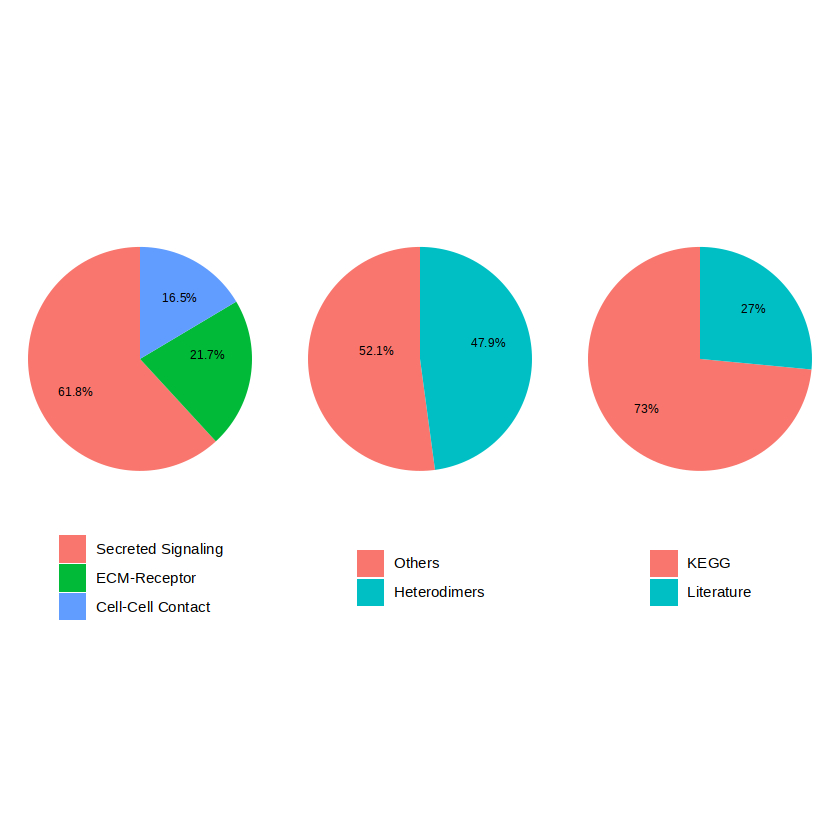

In [41]:
showDatabaseCategory(CellChatDB)

In [42]:
table(meta$cell_type)


 Bas_mig      FB1   Mac_VI   Spi_II VSMC_Con  VSMC_FB 
    1131     2806       41      250     3558     6802 

In [43]:
total5dfu_cellchat <- subsetData(total5dfu_cellchat)

In [44]:
total5dfu_cellchat <- identifyOverExpressedGenes(total5dfu_cellchat)
total5dfu_cellchat <- identifyOverExpressedInteractions(total5dfu_cellchat)

In [45]:
levels(total5dfu_cellchat@idents)
unique(total5dfu_cellchat@idents)

[1] "Bas_mig"  "FB1"      "Mac_VI"   "Spi_II"   "VSMC_Con" "VSMC_FB"

[1] VSMC_FB  VSMC_Con FB1      Bas_mig  Spi_II   Mac_VI  
Levels: Bas_mig FB1 Mac_VI Spi_II VSMC_Con VSMC_FB

In [46]:
idents <- total5dfu_cellchat@idents
idents <- droplevels(idents)
total5dfu_cellchat@idents <- idents

In [47]:
total5dfu_cellchat <- computeCommunProb(total5dfu_cellchat)

triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2025-09-18 15:21:10.88253]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2025-09-18 15:22:42.187191]"


In [48]:
total5dfu_cellchat <- filterCommunication(total5dfu_cellchat, min.cells = 10)

In [49]:
total5dfu_cellchat <- computeCommunProbPathway(total5dfu_cellchat)

In [50]:
total5dfu_cellchat <- aggregateNet(total5dfu_cellchat)

In [51]:
total5dfu_cellchat@net$count
total5dfu_cellchat@net$weight

,Bas_mig,FB1,Mac_VI,Spi_II,VSMC_Con,VSMC_FB
Bas_mig,10,7,0,8,0,0
FB1,21,22,10,21,2,1
Mac_VI,13,15,20,13,1,0
Spi_II,26,24,4,23,1,0
VSMC_Con,14,16,2,14,1,0
VSMC_FB,18,18,4,17,1,0


,Bas_mig,FB1,Mac_VI,Spi_II,VSMC_Con,VSMC_FB
Bas_mig,0.07052012,0.004178853,0.000000000,0.01106946,0.0000000000,0.000000000
FB1,0.47337890,0.150152730,0.063182652,0.13337533,0.0118745520,0.003394744
Mac_VI,0.08662235,0.031916929,0.156315506,0.02425383,0.0010048500,0.000000000
Spi_II,0.26560873,0.079648675,0.007114125,0.07302765,0.0005074786,0.000000000
VSMC_Con,0.12240307,0.040203573,0.007495722,0.03359847,0.0024509638,0.000000000
VSMC_FB,0.24232772,0.075102129,0.008202583,0.06757968,0.0015434975,0.000000000


In [53]:
write.csv(total5dfu_cellchat@net$count, file = "total5dfu_net_count.csv")

write.csv(total5dfu_cellchat@net$weight, file = "total5dfu_net_weight.csv")

## DC

In [52]:
total5control_cells <- which(total5_sce$group == "control")
if(length(total5control_cells) == 0) stop("未找到control细胞")

In [53]:
total5control_sce <- total5_sce[, total5control_cells, drop = FALSE]

In [54]:
reducedDims(total5control_sce) <- list(
  PCA = reducedDim(total5control_sce, "PCA"),
  Harmony = reducedDim(total5control_sce, "Harmony"), 
  UMAP = reducedDim(total5control_sce, "UMAP")
)
names(reducedDims(total5control_sce)) <- c("PCA", "Harmony", "UMAP")

In [55]:
counts <- assay(total5control_sce, "counts")
meta <- as.data.frame(colData(total5control_sce))

In [56]:
rownames(meta) <- colnames(counts)

In [57]:
total5control_cellchat <- createCellChat(
  object = counts,
  meta = meta,
  group.by = "cell_type"  
)

[1] "Create a CellChat object from a data matrix"
The cell barcodes in 'meta' is  1 2 3 4 5 6 


Warning message in createCellChat(object = counts, meta = meta, group.by = "cell_type"):
“The cell barcodes in 'meta' is different from those in the used data matrix.
              We now simply assign the colnames in the data matrix to the rownames of 'mata'!”


Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Bas_mig FB1 Mac_VI Spi_II VSMC_Con VSMC_FB 


In [58]:
total5control_cellchat
summary(total5control_cellchat)
str(total5control_cellchat)

An object of class CellChat created from a single dataset 
 4000 genes.
 2289 cells. 
CellChat analysis of single cell RNA-seq data! 

  Length    Class     Mode 
       1 CellChat       S4 

Formal class 'CellChat' [package "CellChat"] with 15 slots
  ..@ data.raw      : num[0 , 0 ] 
  ..@ data          :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. ..@ i       : int [1:349192] 4 368 378 596 609 680 699 717 726 728 ...
  .. .. ..@ p       : int [1:2290] 0 147 349 479 578 667 882 1097 1206 1299 ...
  .. .. ..@ Dim     : int [1:2] 4000 2289
  .. .. ..@ Dimnames:List of 2
  .. .. .. ..$ : chr [1:4000] "A2M-AS1" "A2ML1" "AARD" "AATK" ...
  .. .. .. ..$ : NULL
  .. .. ..@ x       : num [1:349192] 1.35 1.35 1.35 1.35 1.35 ...
  .. .. ..@ factors : list()
  ..@ data.signaling: num[0 , 0 ] 
  ..@ data.scale    : num[0 , 0 ] 
  ..@ data.project  : num[0 , 0 ] 
  ..@ images        : list()
  ..@ net           : list()
  ..@ netP          : list()
  ..@ meta          :'data.frame':	2289 obs. of  3 variables:
  .. ..$ cell_type: Factor w/ 6 levels "Bas_mig","FB1",..: 2 2 2 2 1 6 2 2 1 2 ...
  .. ..$ leiden   : Factor w/ 8 levels "B Cell","Endothelial Cell",..: 3 3 3

In [59]:
CellChatDB <- CellChatDB.human
total5control_cellchat@DB <- CellChatDB

In [60]:
table(meta$cell_type)


 Bas_mig      FB1   Mac_VI   Spi_II VSMC_Con  VSMC_FB 
      90       58        4       17      726     1394 

In [61]:
total5control_cellchat <- subsetData(total5control_cellchat)

In [62]:
total5control_cellchat <- identifyOverExpressedGenes(total5control_cellchat)
total5control_cellchat <- identifyOverExpressedInteractions(total5control_cellchat)

In [63]:
idents <- total5control_cellchat@idents
idents <- droplevels(idents)
total5control_cellchat@idents <- idents

In [64]:
total5control_cellchat <- computeCommunProb(total5control_cellchat)

triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2025-09-18 15:22:45.139197]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2025-09-18 15:23:31.559317]"


In [65]:
total5control_cellchat <- filterCommunication(total5control_cellchat, min.cells = 10)

The cell-cell communication related with the following cell groups are excluded due to the few number of cells:  Mac_VI 


In [66]:
total5control_cellchat <- computeCommunProbPathway(total5control_cellchat)

In [67]:
total5control_cellchat <- aggregateNet(total5control_cellchat)

In [68]:
total5control_cellchat@net$count
total5control_cellchat@net$weight

,Bas_mig,FB1,Mac_VI,Spi_II,VSMC_Con,VSMC_FB
Bas_mig,4,0,0,1,0,0
FB1,18,9,0,18,1,4
Mac_VI,0,0,0,0,0,0
Spi_II,22,11,0,20,1,3
VSMC_Con,12,7,0,12,1,1
VSMC_FB,12,7,0,12,1,0


,Bas_mig,FB1,Mac_VI,Spi_II,VSMC_Con,VSMC_FB
Bas_mig,0.06733880,0.00000000,0,0.01928397,0.000000000,0.000000000
FB1,0.41855072,0.24067776,0,0.38864649,0.026506787,0.040962479
Mac_VI,0.00000000,0.00000000,0,0.00000000,0.000000000,0.000000000
Spi_II,0.14585686,0.08556439,0,0.12978391,0.003667261,0.015298494
VSMC_Con,0.07240073,0.04472680,0,0.06707883,0.002244633,0.002073979
VSMC_FB,0.15992501,0.10251122,0,0.14828443,0.007663351,0.000000000


In [71]:
write.csv(total5control_cellchat@net$count, file = "/cluster/home/chenyulong/GSE165816/0.1out/total5control_net_count.csv")

write.csv(total5control_cellchat@net$weight, file = "/cluster/home/chenyulong/GSE165816/0.1out/total5control_net_weight.csv")